# Guide II: Interpreting Predictions & Understanding Limits

## Time-Series Forecasting and Model Evaluation

**Real-World Application: Predicting Global Health Trends**

This notebook demonstrates how data science can support decision-making on critical social issues. We'll use time-series analysis to evaluate prediction reliability for urgent problems like disease prevention, poverty reduction, or environmental monitoring.

By understanding model limitations and communicating uncertainty honestly, organizations can make better decisions about resource allocation, policy interventions, and impact measurement.


## 1. Import Required Libraries


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# Set style for visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("Libraries imported successfully!")


Libraries imported successfully!


## 2. Load and Prepare Time-Series Data


Dataset Overview:
Shape: (200, 1)
Date range: 2020-01-01 00:00:00 to 2020-07-18 00:00:00

First few rows:
                 value
date                  
2020-01-01  102.483571
2020-01-02  101.639052
2020-01-03  107.808322
2020-01-04  114.246771
2020-01-05  107.265707

Basic statistics:
            value
count  200.000000
mean   125.174584
std     16.915901
min     88.709935
25%    111.867562
50%    125.834403
75%    137.355549
max    159.703392


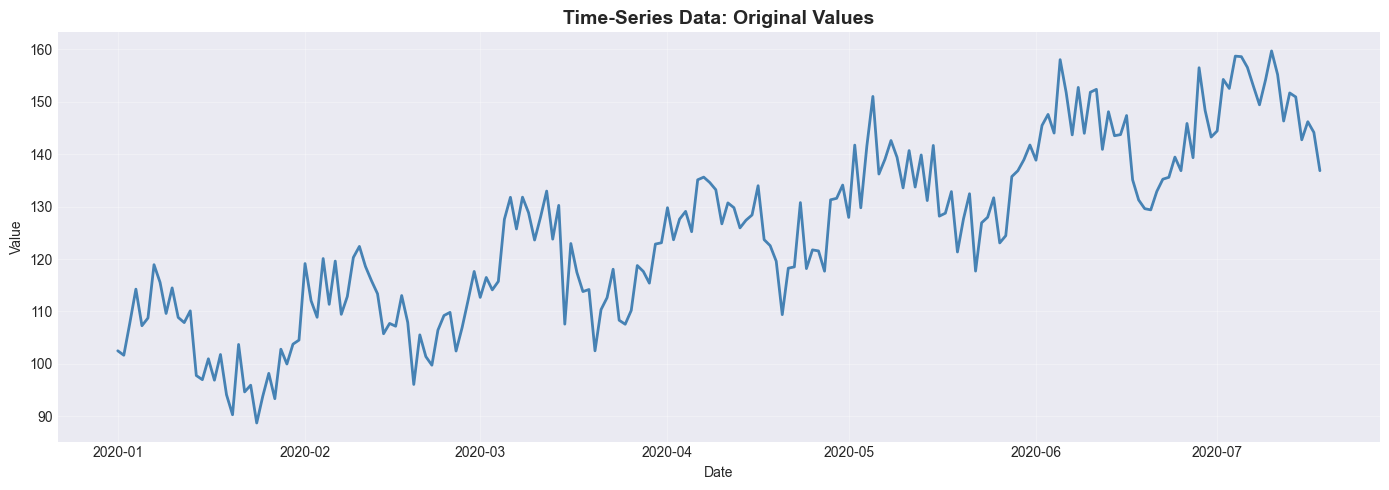

In [2]:
# Create a synthetic time-series dataset
np.random.seed(42)
dates = pd.date_range('2020-01-01', periods=200, freq='D')
trend = np.linspace(0, 50, 200)
seasonality = 10 * np.sin(np.arange(200) * 2 * np.pi / 30)
noise = np.random.normal(0, 5, 200)
values = 100 + trend + seasonality + noise

data = pd.DataFrame({
    'date': dates,
    'value': values
})

data.set_index('date', inplace=True)

print("Dataset Overview:")
print(f"Shape: {data.shape}")
print(f"Date range: {data.index[0]} to {data.index[-1]}")
print(f"\nFirst few rows:")
print(data.head())
print(f"\nBasic statistics:")
print(data.describe())

# Visualize the original time-series
plt.figure(figsize=(14, 5))
plt.plot(data.index, data['value'], linewidth=2, color='steelblue')
plt.title('Time-Series Data: Original Values', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Value')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [3]:
# Create lagged features for prediction
def create_lagged_features(data, lag=5):
    """Create lagged features for time-series modeling."""
    df = data.copy()
    
    for i in range(1, lag + 1):
        df[f'lag_{i}'] = df['value'].shift(i)
    
    df = df.dropna()
    return df

# Create lagged features
lag_value = 5
data_features = create_lagged_features(data[['value']], lag=lag_value)

print(f"Features created with lag={lag_value}")
print(f"Shape after creating features: {data_features.shape}")
print(f"\nFirst few rows with lagged features:")
print(data_features.head())

# Prepare X and y
X = data_features.drop('value', axis=1).values
y = data_features['value'].values

print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")


Features created with lag=5
Shape after creating features: (195, 6)

First few rows with lagged features:
                 value       lag_1       lag_2       lag_3       lag_4  \
date                                                                     
2020-01-06  108.745851  107.265707  114.246771  107.808322  101.639052   
2020-01-07  118.914167  108.745851  107.265707  114.246771  107.808322   
2020-01-08  115.541187  118.914167  108.745851  107.265707  114.246771   
2020-01-09  109.607897  115.541187  118.914167  108.745851  107.265707   
2020-01-10  114.484672  109.607897  115.541187  118.914167  108.745851   

                 lag_5  
date                    
2020-01-06  102.483571  
2020-01-07  101.639052  
2020-01-08  107.808322  
2020-01-09  114.246771  
2020-01-10  107.265707  

X shape: (195, 5)
y shape: (195,)


## 3. Train a Time-Series Model

We'll train a simple linear regression model on the training data to make predictions.


Training set size: 156 (80.0%)
Test set size: 39 (20.0%)

Model trained successfully!
Model coefficients shape: (5,)
Model intercept: 5.1851


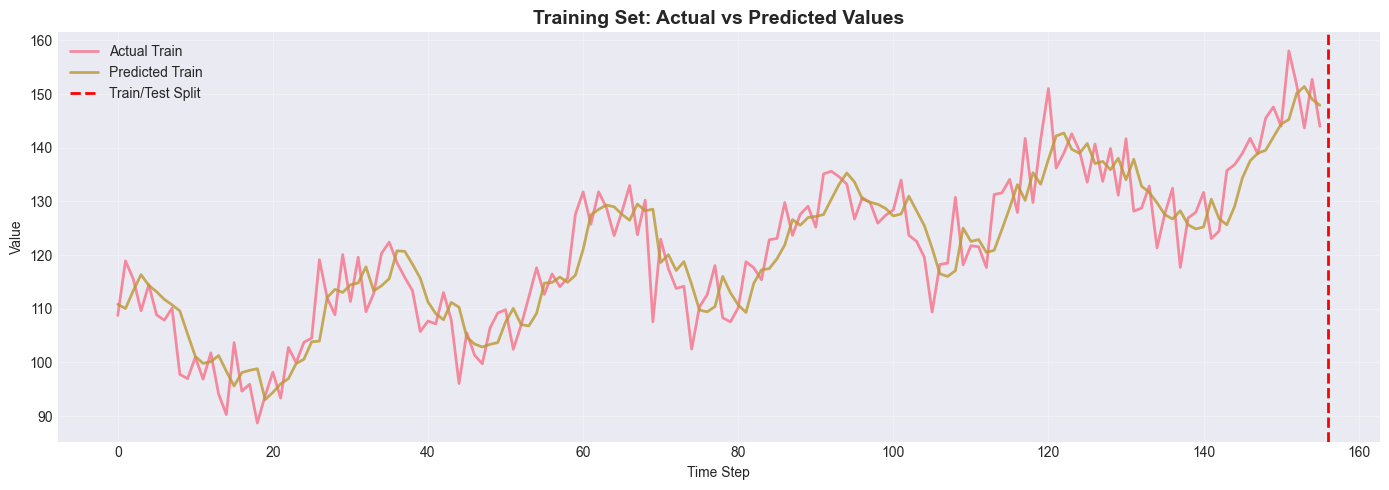

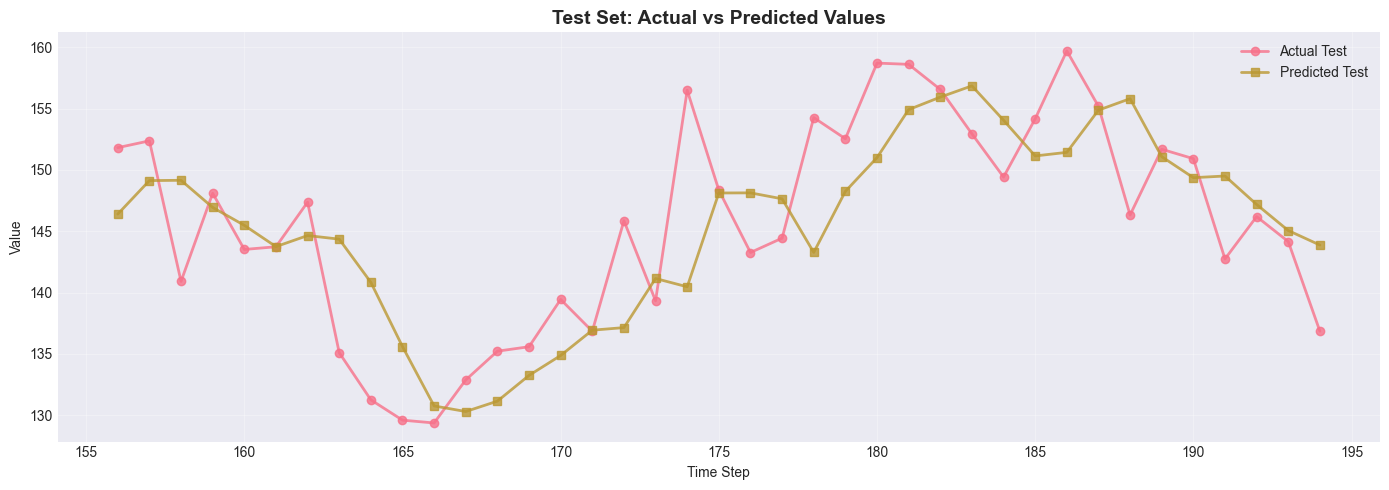

In [4]:
# Train/test split (respecting temporal order)
split_idx = int(len(X) * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

print(f"Training set size: {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
print(f"Test set size: {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)")

# Train linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

print(f"\nModel trained successfully!")
print(f"Model coefficients shape: {model.coef_.shape}")
print(f"Model intercept: {model.intercept_:.4f}")

# Visualize predictions on training set
plt.figure(figsize=(14, 5))
plt.plot(range(len(y_train)), y_train, label='Actual Train', linewidth=2, alpha=0.8)
plt.plot(range(len(y_train)), y_pred_train, label='Predicted Train', linewidth=2, alpha=0.8)
plt.axvline(x=len(y_train), color='red', linestyle='--', linewidth=2, label='Train/Test Split')
plt.title('Training Set: Actual vs Predicted Values', fontsize=14, fontweight='bold')
plt.xlabel('Time Step')
plt.ylabel('Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Visualize predictions on test set
plt.figure(figsize=(14, 5))
test_idx = range(len(y_train), len(y_train) + len(y_test))
plt.plot(test_idx, y_test, label='Actual Test', linewidth=2, marker='o', markersize=6, alpha=0.8)
plt.plot(test_idx, y_pred_test, label='Predicted Test', linewidth=2, marker='s', markersize=6, alpha=0.8)
plt.title('Test Set: Actual vs Predicted Values', fontsize=14, fontweight='bold')
plt.xlabel('Time Step')
plt.ylabel('Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 4. Calculate MSE and RMSE

**Mean Squared Error (MSE)** and **Root Mean Squared Error (RMSE)** measure average prediction error.

$$MSE = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2$$

$$RMSE = \sqrt{MSE}$$

- **MSE**: Emphasizes larger errors (quadratic penalty)
- **RMSE**: Returns to original scale, more interpretable
- **Limitation**: Sensitive to outliers due to squaring


MSE & RMSE Metrics

Training Set:
  MSE:  37.3177
  RMSE: 6.1088

Test Set:
  MSE:  32.6020
  RMSE: 5.7098


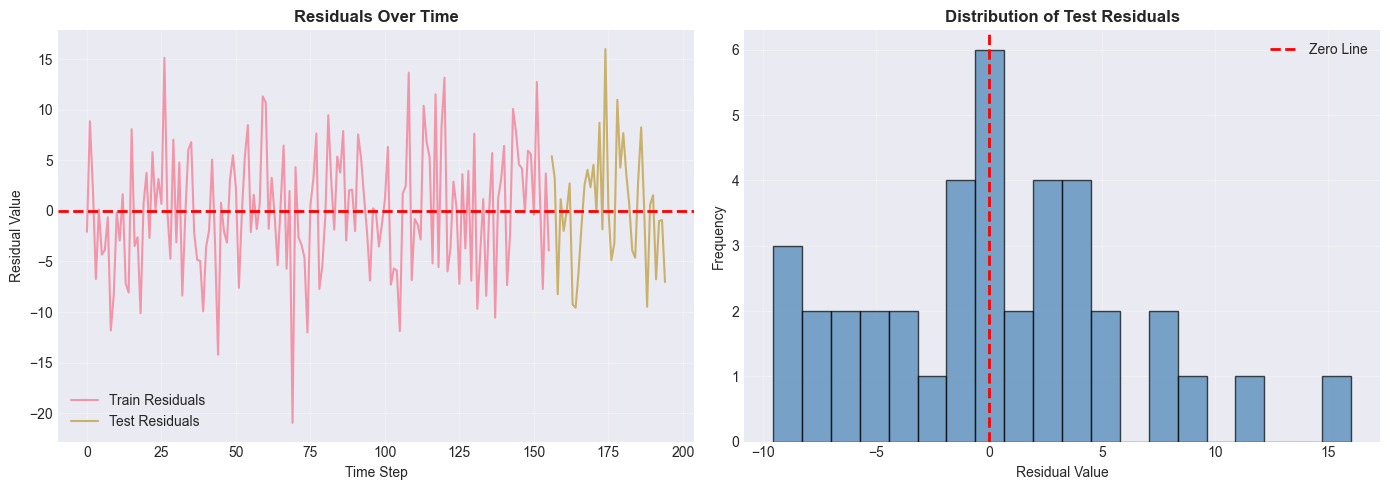

In [5]:
# Calculate MSE and RMSE
mse_train = mean_squared_error(y_train, y_pred_train)
rmse_train = np.sqrt(mse_train)

mse_test = mean_squared_error(y_test, y_pred_test)
rmse_test = np.sqrt(mse_test)

print("=" * 60)
print("MSE & RMSE Metrics")
print("=" * 60)
print(f"\nTraining Set:")
print(f"  MSE:  {mse_train:.4f}")
print(f"  RMSE: {rmse_train:.4f}")

print(f"\nTest Set:")
print(f"  MSE:  {mse_test:.4f}")
print(f"  RMSE: {rmse_test:.4f}")

# Calculate residuals for analysis
residuals_train = y_train - y_pred_train
residuals_test = y_test - y_pred_test

# Visualize residuals
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residuals over time
axes[0].plot(residuals_train, label='Train Residuals', alpha=0.7, linewidth=1.5)
axes[0].plot(range(len(y_train), len(y_train) + len(residuals_test)), residuals_test, 
             label='Test Residuals', alpha=0.7, linewidth=1.5)
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[0].set_title('Residuals Over Time', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Time Step')
axes[0].set_ylabel('Residual Value')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Residuals distribution
axes[1].hist(residuals_test, bins=20, alpha=0.7, edgecolor='black', color='steelblue')
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Line')
axes[1].set_title('Distribution of Test Residuals', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Residual Value')
axes[1].set_ylabel('Frequency')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 5. Calculate WAPE and MAPE

**Mean Absolute Percentage Error (MAPE)** and **Weighted Absolute Percentage Error (WAPE)** are percentage-based metrics.

$$MAPE = \frac{1}{n}\sum_{i=1}^{n}\frac{|y_i - \hat{y}_i|}{|y_i|} \times 100$$

$$WAPE = \frac{\sum|y_i - \hat{y}_i|}{\sum|y_i|} \times 100$$

- **MAPE**: Individual percentage errors averaged
- **WAPE**: Prevents extreme values from dominating
- **Advantage**: Scale-independent, easy to interpret
- **Limitation**: Undefined when actual=0; can be misleading with small values


In [6]:
# Define MAPE and WAPE functions
def calculate_mape(y_actual, y_pred):
    """Calculate Mean Absolute Percentage Error"""
    # Avoid division by zero
    mask = y_actual != 0
    mape = np.mean(np.abs((y_actual[mask] - y_pred[mask]) / y_actual[mask])) * 100
    return mape

def calculate_wape(y_actual, y_pred):
    """Calculate Weighted Absolute Percentage Error"""
    numerator = np.sum(np.abs(y_actual - y_pred))
    denominator = np.sum(np.abs(y_actual))
    if denominator == 0:
        return 0
    wape = (numerator / denominator) * 100
    return wape

# Calculate MAPE and WAPE
mape_train = calculate_mape(y_train, y_pred_train)
wape_train = calculate_wape(y_train, y_pred_train)

mape_test = calculate_mape(y_test, y_pred_test)
wape_test = calculate_wape(y_test, y_pred_test)

print("=" * 60)
print("MAPE & WAPE Metrics (Percentage-Based)")
print("=" * 60)
print(f"\nTraining Set:")
print(f"  MAPE: {mape_train:.2f}%")
print(f"  WAPE: {wape_train:.2f}%")

print(f"\nTest Set:")
print(f"  MAPE: {mape_test:.2f}%")
print(f"  WAPE: {wape_test:.2f}%")

# Summary table
metrics_summary = pd.DataFrame({
    'Metric': ['MSE', 'RMSE', 'MAPE (%)', 'WAPE (%)'],
    'Train': [mse_train, rmse_train, mape_train, wape_train],
    'Test': [mse_test, rmse_test, mape_test, wape_test]
})

print("\n" + "=" * 60)
print("All Metrics Summary")
print("=" * 60)
print(metrics_summary.to_string(index=False))


MAPE & WAPE Metrics (Percentage-Based)

Training Set:
  MAPE: 4.09%
  WAPE: 4.04%

Test Set:
  MAPE: 3.03%
  WAPE: 3.03%

All Metrics Summary
  Metric     Train      Test
     MSE 37.317714 32.601999
    RMSE  6.108823  5.709816
MAPE (%)  4.089019  3.032948
WAPE (%)  4.037906  3.031093


## 6. Implement K-Fold Cross-Validation for Time-Series

Time-series k-fold cross-validation uses **forward-chaining** to respect temporal order and avoid data leakage.

**Key principle:** Train on earlier data, test on later data. Never train on future data!


In [7]:
# Implement TimeSeriesSplit for k-fold cross-validation
n_splits = 5
tscv = TimeSeriesSplit(n_splits=n_splits)

# Store results for each fold
fold_results = []
fold_metrics = {
    'mse': [],
    'rmse': [],
    'mape': [],
    'wape': [],
    'fold': []
}

print("=" * 60)
print(f"Time-Series {n_splits}-Fold Cross-Validation")
print("=" * 60)

for fold_idx, (train_idx, test_idx) in enumerate(tscv.split(X)):
    # Split data
    X_cv_train, X_cv_test = X[train_idx], X[test_idx]
    y_cv_train, y_cv_test = y[train_idx], y[test_idx]
    
    # Train model
    model_cv = LinearRegression()
    model_cv.fit(X_cv_train, y_cv_train)
    
    # Make predictions
    y_cv_pred = model_cv.predict(X_cv_test)
    
    # Calculate metrics
    mse = mean_squared_error(y_cv_test, y_cv_pred)
    rmse = np.sqrt(mse)
    mape = calculate_mape(y_cv_test, y_cv_pred)
    wape = calculate_wape(y_cv_test, y_cv_pred)
    
    # Store results
    fold_metrics['mse'].append(mse)
    fold_metrics['rmse'].append(rmse)
    fold_metrics['mape'].append(mape)
    fold_metrics['wape'].append(wape)
    fold_metrics['fold'].append(fold_idx + 1)
    
    fold_results.append({
        'fold': fold_idx + 1,
        'train_size': len(train_idx),
        'test_size': len(test_idx),
        'mse': mse,
        'rmse': rmse,
        'mape': mape,
        'wape': wape
    })
    
    print(f"\nFold {fold_idx + 1}:")
    print(f"  Train size: {len(train_idx)}, Test size: {len(test_idx)}")
    print(f"  MSE:  {mse:.4f}, RMSE: {rmse:.4f}")
    print(f"  MAPE: {mape:.2f}%, WAPE: {wape:.2f}%")

# Create results DataFrame
cv_results_df = pd.DataFrame(fold_results)

print("\n" + "=" * 60)
print("Cross-Validation Results Summary")
print("=" * 60)
print(cv_results_df.to_string(index=False))


Time-Series 5-Fold Cross-Validation

Fold 1:
  Train size: 35, Test size: 32
  MSE:  37.8084, RMSE: 6.1489
  MAPE: 3.88%, WAPE: 3.91%

Fold 2:
  Train size: 67, Test size: 32
  MSE:  41.0504, RMSE: 6.4071
  MAPE: 4.09%, WAPE: 3.98%

Fold 3:
  Train size: 99, Test size: 32
  MSE:  46.9312, RMSE: 6.8506
  MAPE: 4.31%, WAPE: 4.35%

Fold 4:
  Train size: 131, Test size: 32
  MSE:  36.1517, RMSE: 6.0126
  MAPE: 3.65%, WAPE: 3.61%

Fold 5:
  Train size: 163, Test size: 32
  MSE:  36.3392, RMSE: 6.0282
  MAPE: 3.22%, WAPE: 3.22%

Cross-Validation Results Summary
 fold  train_size  test_size       mse     rmse     mape     wape
    1          35         32 37.808421 6.148855 3.878562 3.910553
    2          67         32 41.050400 6.407059 4.093695 3.984449
    3          99         32 46.931195 6.850635 4.307994 4.349341
    4         131         32 36.151720 6.012630 3.645222 3.606056
    5         163         32 36.339197 6.028200 3.219599 3.220143


## 7. Visualize Prediction Errors


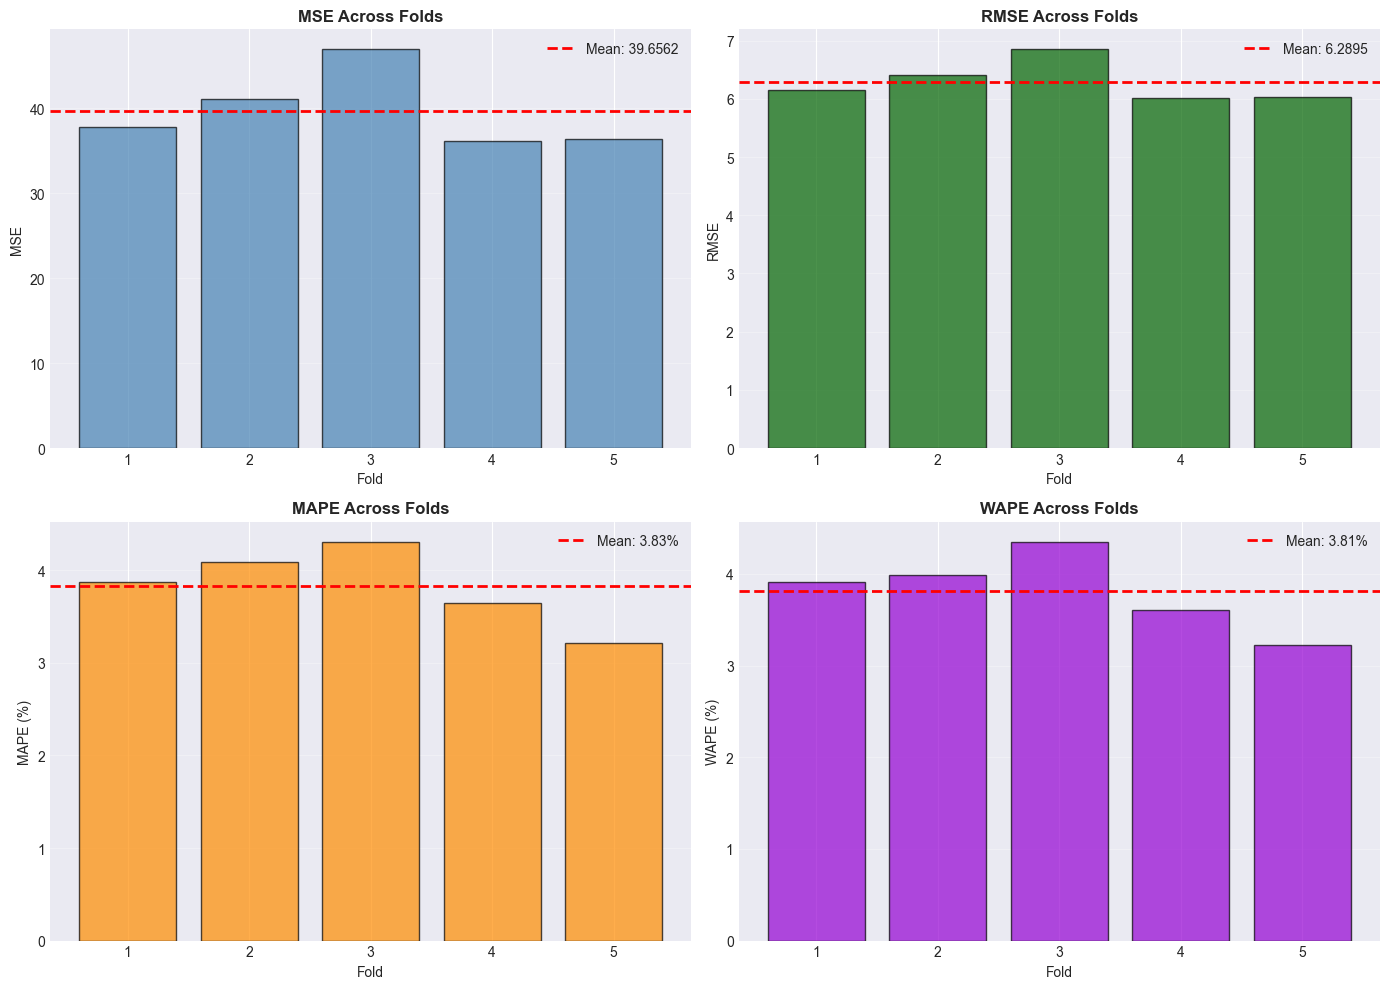

In [8]:
# Visualize errors across folds
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: MSE across folds
axes[0, 0].bar(cv_results_df['fold'], cv_results_df['mse'], 
               color='steelblue', alpha=0.7, edgecolor='black')
axes[0, 0].axhline(cv_results_df['mse'].mean(), color='red', linestyle='--', 
                   linewidth=2, label=f'Mean: {cv_results_df["mse"].mean():.4f}')
axes[0, 0].set_title('MSE Across Folds', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Fold')
axes[0, 0].set_ylabel('MSE')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3, axis='y')

# Plot 2: RMSE across folds
axes[0, 1].bar(cv_results_df['fold'], cv_results_df['rmse'], 
               color='darkgreen', alpha=0.7, edgecolor='black')
axes[0, 1].axhline(cv_results_df['rmse'].mean(), color='red', linestyle='--', 
                   linewidth=2, label=f'Mean: {cv_results_df["rmse"].mean():.4f}')
axes[0, 1].set_title('RMSE Across Folds', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Fold')
axes[0, 1].set_ylabel('RMSE')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Plot 3: MAPE across folds
axes[1, 0].bar(cv_results_df['fold'], cv_results_df['mape'], 
               color='darkorange', alpha=0.7, edgecolor='black')
axes[1, 0].axhline(cv_results_df['mape'].mean(), color='red', linestyle='--', 
                   linewidth=2, label=f'Mean: {cv_results_df["mape"].mean():.2f}%')
axes[1, 0].set_title('MAPE Across Folds', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Fold')
axes[1, 0].set_ylabel('MAPE (%)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Plot 4: WAPE across folds
axes[1, 1].bar(cv_results_df['fold'], cv_results_df['wape'], 
               color='darkviolet', alpha=0.7, edgecolor='black')
axes[1, 1].axhline(cv_results_df['wape'].mean(), color='red', linestyle='--', 
                   linewidth=2, label=f'Mean: {cv_results_df["wape"].mean():.2f}%')
axes[1, 1].set_title('WAPE Across Folds', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Fold')
axes[1, 1].set_ylabel('WAPE (%)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


## 8. Compare Metrics Across Folds

Calculate mean and standard deviation to assess model stability and reliability.



Cross-Validation Metrics Statistics
  Metric      Mean  Std Dev       Min       Max
     MSE 39.656187 4.515737 36.151720 46.931195
    RMSE  6.289476 0.351215  6.012630  6.850635
MAPE (%)  3.829015 0.420446  3.219599  4.307994
WAPE (%)  3.814109 0.424521  3.220143  4.349341

Key Insights & Interpretation

1. MODEL STABILITY:
   - MSE Std Dev:   4.5157 (measures consistency)
   - RMSE Std Dev:  0.3512
   - Low std indicates stable, reliable predictions
   - High std indicates variable performance across time periods

2. SCALE SENSITIVITY:
   - MSE/RMSE: Absolute error scale (in original units)
   - MAPE/WAPE: Percentage-based (scale-independent)
   
3. WHEN TO USE EACH METRIC:
   ✓ MSE/RMSE: When all errors should be weighted equally
   ✓ MAPE: When you want percentage accuracy
   ✓ WAPE: When you want to avoid extreme percentage errors
   
4. PERFORMANCE ASSESSMENT:
   - RMSE Mean: 6.2895
   - This means predictions are off by ~6.2895 units on average
   - MAPE Mean: 3.83%
   - This 

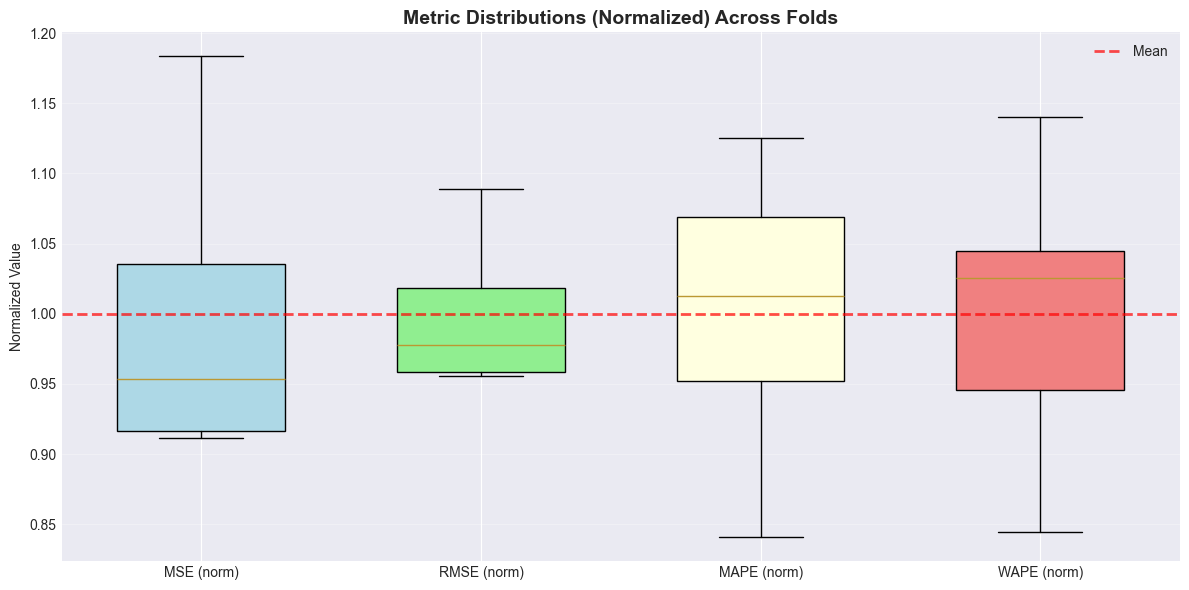

In [9]:
# Calculate statistics for all metrics
metrics_stats = pd.DataFrame({
    'Metric': ['MSE', 'RMSE', 'MAPE (%)', 'WAPE (%)'],
    'Mean': [
        cv_results_df['mse'].mean(),
        cv_results_df['rmse'].mean(),
        cv_results_df['mape'].mean(),
        cv_results_df['wape'].mean()
    ],
    'Std Dev': [
        cv_results_df['mse'].std(),
        cv_results_df['rmse'].std(),
        cv_results_df['mape'].std(),
        cv_results_df['wape'].std()
    ],
    'Min': [
        cv_results_df['mse'].min(),
        cv_results_df['rmse'].min(),
        cv_results_df['mape'].min(),
        cv_results_df['wape'].min()
    ],
    'Max': [
        cv_results_df['mse'].max(),
        cv_results_df['rmse'].max(),
        cv_results_df['mape'].max(),
        cv_results_df['wape'].max()
    ]
})

print("\n" + "=" * 80)
print("Cross-Validation Metrics Statistics")
print("=" * 80)
print(metrics_stats.to_string(index=False))

# Interpretation
print("\n" + "=" * 80)
print("Key Insights & Interpretation")
print("=" * 80)

print(f"""
1. MODEL STABILITY:
   - MSE Std Dev:   {cv_results_df['mse'].std():.4f} (measures consistency)
   - RMSE Std Dev:  {cv_results_df['rmse'].std():.4f}
   - Low std indicates stable, reliable predictions
   - High std indicates variable performance across time periods

2. SCALE SENSITIVITY:
   - MSE/RMSE: Absolute error scale (in original units)
   - MAPE/WAPE: Percentage-based (scale-independent)
   
3. WHEN TO USE EACH METRIC:
   ✓ MSE/RMSE: When all errors should be weighted equally
   ✓ MAPE: When you want percentage accuracy
   ✓ WAPE: When you want to avoid extreme percentage errors
   
4. PERFORMANCE ASSESSMENT:
   - RMSE Mean: {cv_results_df['rmse'].mean():.4f}
   - This means predictions are off by ~{cv_results_df['rmse'].mean():.4f} units on average
   - MAPE Mean: {cv_results_df['mape'].mean():.2f}%
   - This is a {cv_results_df['mape'].mean():.2f}% average percentage error

5. RELIABILITY:
   - Coefficient of Variation (RMSE):  {(cv_results_df['rmse'].std() / cv_results_df['rmse'].mean() * 100):.2f}%
   - Lower CV% = more stable, reliable model
""")

# Create comparison boxplot
plt.figure(figsize=(12, 6))

# Normalize metrics for visualization (for comparison)
data_to_plot = [
    cv_results_df['mse'] / cv_results_df['mse'].mean(),
    cv_results_df['rmse'] / cv_results_df['rmse'].mean(),
    cv_results_df['mape'] / cv_results_df['mape'].mean(),
    cv_results_df['wape'] / cv_results_df['wape'].mean()
]

bp = plt.boxplot(data_to_plot, labels=['MSE (norm)', 'RMSE (norm)', 'MAPE (norm)', 'WAPE (norm)'],
                 patch_artist=True, widths=0.6)

colors = ['lightblue', 'lightgreen', 'lightyellow', 'lightcoral']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

plt.axhline(y=1, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Mean')
plt.title('Metric Distributions (Normalized) Across Folds', fontsize=14, fontweight='bold')
plt.ylabel('Normalized Value')
plt.grid(True, alpha=0.3, axis='y')
plt.legend()
plt.tight_layout()
plt.show()


## Summary: Understanding Limits of Predictions

### Key Takeaways:

1. **No Perfect Predictions**: All errors are non-zero. This is normal and expected.

2. **Choose Appropriate Metrics**:
   - Use **MSE/RMSE** when large errors should be penalized
   - Use **MAPE/WAPE** for percentage-based comparison across scales
   - Use **multiple metrics** to get complete picture

3. **K-Fold CV Respects Temporal Order**: 
   - Forward-chaining prevents data leakage
   - Tests realistic time-series prediction scenarios
   - Shows if model works consistently across time

4. **Stability is Key**:
   - Low standard deviation = reliable model
   - High std dev = model performs differently at different times
   - May need different models for different time periods

5. **Model Limitations**:
   - Cannot predict beyond learned patterns
   - Sensitive to anomalies and regime changes
   - Performance degrades without recent training data
   - External factors not in data can cause failures

### When NOT to Trust Predictions:
   ❌ During unusual market conditions
   ❌ With incomplete or biased data
   ❌ Far into the future (extrapolation risk)
   ❌ When high-volatility changes are expected
   ❌ If new factors not seen in training data emerge

### Next Steps:
1. Try different models (ARIMA, exponential smoothing, neural networks)
2. Engineer better features
3. Analyze why low-performing folds had worse results
4. Add external data that improves predictions
5. Use ensemble methods to combine multiple models


## Bonus: Confidence Intervals & Interactive Plotly Visualization

**Confidence intervals** show the range where predictions likely fall. A 95% confidence interval means we expect the true value to be in this range 95% of the time.

This helps you understand **how certain** your predictions are, not just what they are.


In [10]:
import plotly.graph_objects as go
from scipy import stats

# Calculate confidence intervals for test predictions
confidence_level = 0.95
alpha = 1 - confidence_level

# Calculate standard error of predictions
residuals = y_test - y_pred_test
std_error = np.std(residuals)

# Calculate margin of error (95% CI)
# Using t-distribution (more accurate for small samples)
t_score = stats.t.ppf(1 - alpha/2, len(residuals) - 1)
margin_of_error = t_score * std_error

# Create confidence intervals
ci_upper = y_pred_test + margin_of_error
ci_lower = y_pred_test - margin_of_error

print("=" * 60)
print("Confidence Intervals for Test Predictions")
print("=" * 60)
print(f"\nConfidence Level: {confidence_level*100:.0f}%")
print(f"Standard Error: {std_error:.4f}")
print(f"Margin of Error: ±{margin_of_error:.4f}")
print(f"\nExample predictions with 95% CI:")
for i in range(min(5, len(y_test))):
    print(f"  Actual: {y_test[i]:.2f}")
    print(f"  Predicted: {y_pred_test[i]:.2f}")
    print(f"  95% CI: [{ci_lower[i]:.2f}, {ci_upper[i]:.2f}]")
    print(f"  Within CI: {'✓ YES' if ci_lower[i] <= y_test[i] <= ci_upper[i] else '✗ NO'}")
    print()

# Create interactive Plotly visualization
time_index = np.arange(len(y_test))

fig = go.Figure()

# Add confidence interval as shaded area
fig.add_trace(go.Scatter(
    x=time_index,
    y=ci_upper,
    fill=None,
    mode='lines',
    line_color='rgba(0,0,0,0)',
    showlegend=False,
    name='Upper CI'
))

fig.add_trace(go.Scatter(
    x=time_index,
    y=ci_lower,
    fill='tonexty',
    mode='lines',
    line_color='rgba(0,0,0,0)',
    name='95% Confidence Interval',
    fillcolor='rgba(68, 68, 68, 0.2)'
))

# Add actual values
fig.add_trace(go.Scatter(
    x=time_index,
    y=y_test,
    mode='lines+markers',
    name='Actual Values',
    line=dict(color='blue', width=2),
    marker=dict(size=6)
))

# Add predictions
fig.add_trace(go.Scatter(
    x=time_index,
    y=y_pred_test,
    mode='lines+markers',
    name='Predictions',
    line=dict(color='red', width=2, dash='dash'),
    marker=dict(size=6, symbol='diamond')
))

# Update layout
fig.update_layout(
    title='Test Set: Predictions with 95% Confidence Intervals',
    xaxis_title='Time Step',
    yaxis_title='Value',
    hovermode='x unified',
    height=600,
    template='plotly_white',
    font=dict(size=12),
    legend=dict(
        yanchor='top',
        y=0.99,
        xanchor='left',
        x=0.01
    )
)

fig.show()

print("\n" + "=" * 60)
print("What Confidence Intervals Tell You:")
print("=" * 60)
print(f"""
✓ WIDER intervals = LESS CERTAIN predictions
✗ NARROWER intervals = MORE CERTAIN predictions

✓ If actual value is INSIDE CI = model worked well
✗ If actual value is OUTSIDE CI = prediction was unreliable

Percentage of actuals within CI: {np.sum((ci_lower <= y_test) & (y_test <= ci_upper)) / len(y_test) * 100:.1f}%
(Should be close to 95% for well-calibrated model)
""")


Confidence Intervals for Test Predictions

Confidence Level: 95%
Standard Error: 5.7015
Margin of Error: ±11.5421

Example predictions with 95% CI:
  Actual: 151.82
  Predicted: 146.40
  95% CI: [134.86, 157.95]
  Within CI: ✓ YES

  Actual: 152.37
  Predicted: 149.13
  95% CI: [137.59, 160.68]
  Within CI: ✓ YES

  Actual: 140.92
  Predicted: 149.16
  95% CI: [137.62, 160.70]
  Within CI: ✓ YES

  Actual: 148.10
  Predicted: 146.95
  95% CI: [135.40, 158.49]
  Within CI: ✓ YES

  Actual: 143.52
  Predicted: 145.49
  95% CI: [133.95, 157.03]
  Within CI: ✓ YES




What Confidence Intervals Tell You:

✓ WIDER intervals = LESS CERTAIN predictions
✗ NARROWER intervals = MORE CERTAIN predictions

✓ If actual value is INSIDE CI = model worked well
✗ If actual value is OUTSIDE CI = prediction was unreliable

Percentage of actuals within CI: 97.4%
(Should be close to 95% for well-calibrated model)



In [11]:
# Alternative: Using Plotly error bars
fig_errorbars = go.Figure()

# Add predictions with error bars
fig_errorbars.add_trace(go.Scatter(
    x=time_index,
    y=y_pred_test,
    error_y=dict(
        type='data',
        array=margin_of_error * np.ones_like(y_pred_test),
        visible=True,
        color='rgba(100, 100, 200, 0.5)'
    ),
    mode='lines+markers',
    name='Predictions (±95% CI)',
    line=dict(color='darkblue', width=2),
    marker=dict(size=7, color='darkblue')
))

# Add actual values
fig_errorbars.add_trace(go.Scatter(
    x=time_index,
    y=y_test,
    mode='lines+markers',
    name='Actual Values',
    line=dict(color='green', width=2, dash='dash'),
    marker=dict(size=7, color='green', symbol='diamond')
))

fig_errorbars.update_layout(
    title='Test Set: Predictions with Error Bars (95% CI)',
    xaxis_title='Time Step',
    yaxis_title='Value',
    hovermode='x unified',
    height=600,
    template='plotly_white',
    font=dict(size=12)
)

fig_errorbars.show()

print("\n✓ Two ways to visualize confidence intervals in Plotly:")
print("  1. Shaded area (continuous), 2. Error bars (discrete points)")



✓ Two ways to visualize confidence intervals in Plotly:
  1. Shaded area (continuous), 2. Error bars (discrete points)


## Putting It All Together: Decision Making with Predictions

**Use these insights to decide if predictions are reliable enough for real-world decisions:**


## Communicating Predictions & Uncertainty

**The most important skill:** Explaining your results to people who aren't data scientists.

### Translation Guide: Metrics to Business Language

| Technical | Plain English | Example |
|-----------|---------------|---------|
| RMSE = 5.2 | "Predictions are off by ~5.2 units on average" | "Forecasts are typically off by ±$5,200" |
| MAPE = 8% | "Model is 92% accurate" or "Predictions miss by 8%" | "We get within 8% of actual sales 95% of the time" |
| 95% CI: [90, 110] | "We're 95% confident the actual value between 90-110" | "If this situation repeated 100 times, 95 times the result would be in this range" |
| High variance | "Performance varies depending on time period" | "Model works great in Q2 but struggles in Q4" |

### How to Present Your Results

**❌ DON'T SAY:**
- "The model predicts 100" (implies false certainty)
- "RMSE of 5.2 indicates..." (technical jargon)
- "This algorithm uses machine learning to..." (not relevant to decision-makers)

**✓ DO SAY:**
- "We expect around 100, but it could reasonably be anywhere from 95-105"
- "On average, we're off by about 5 units"
- "Based on historical patterns, here's what might happen..."

### Creating Your Stakeholder Presentation

**Tell this story:**

1. **The Context** (30 seconds)
   - What are you predicting? Why does it matter?
   - Example: "We're forecasting next month's website traffic to plan server capacity"

2. **How Confident Are We?** (30 seconds)
   - Show the confidence interval visualization
   - Use plain language: "We're pretty confident (95% sure) traffic will be between X and Y"

3. **What Could Go Wrong?** (30 seconds)
   - Honest limitations
   - "This assumes current trends continue. A major marketing campaign could change everything."

4. **What Should You Do?** (30 seconds)
   - Action items based on the predictions
   - "Plan for the high end (Y) to be safe, monitor actual numbers weekly"

In [12]:
print("=" * 80)
print("DECISION FRAMEWORK: When to Trust Your Predictions")
print("=" * 80)

# Calculate trust metrics
percentage_in_ci = np.sum((ci_lower <= y_test) & (y_test <= ci_upper)) / len(y_test) * 100
avg_ci_width = np.mean(ci_upper - ci_lower)
avg_actual = np.mean(y_test)
avg_mape = cv_results_df['mape'].mean()
rmse_pct = (rmse_test / avg_actual) * 100

decision_rules = f"""
Your Model's Reliability Scorecard:
{'='*80}

1. PREDICTION ACCURACY (RMSE):
   ✓ RMSE: {rmse_test:.4f} ({rmse_pct:.1f}% of average value)
   → If RMSE < 5% of average: Predictions are quite accurate
   → If RMSE > 20% of average: Be cautious with predictions

2. PERCENTAGE ERROR (MAPE):
   ✓ MAPE: {avg_mape:.2f}%
   → If MAPE < 10%: Very good, predictions are reliable
   → If MAPE 10-20%: Acceptable for many applications
   → If MAPE > 20%: Use with caution, consider other models

3. PREDICTION CERTAINTY (Confidence Intervals):
   ✓ Actual values within 95% CI: {percentage_in_ci:.1f}%
   ✓ Average CI width: {avg_ci_width:.4f}
   → If ~95% of actuals in CI: Model is well-calibrated (✓ GOOD)
   → If < 90% in CI: Model is overconfident (may be missing uncertainty)
   → If > 98% in CI: Model is underconfident (too wide intervals)

4. CONSISTENCY (Cross-Val Std Dev):
   ✓ RMSE Std Dev across folds: {cv_results_df['rmse'].std():.4f}
   → Low std dev = consistent performance (✓ GOOD for deployment)
   → High std dev = inconsistent (performance depends on time period)

{'='*80}
DECISION MATRIX:
{'='*80}

┌─────────────┬──────────────────────────────────────────────────┐
│ Metrics     │ Trust Level & Recommendation                     │
├─────────────┼──────────────────────────────────────────────────┤
│ RMSE: {rmse_test:.2f}    │ """.strip()

if rmse_test < avg_actual * 0.05:
    decision_rules += "✓ EXCELLENT: Use for business decisions"
elif rmse_test < avg_actual * 0.10:
    decision_rules += "✓ GOOD: Use with confidence"
elif rmse_test < avg_actual * 0.20:
    decision_rules += "⚠ MODERATE: Use, but consider alternatives"
else:
    decision_rules += "✗ POOR: Seek better model or more data"

decision_rules += f"""
│ MAPE: {avg_mape:.1f}%   │ """.strip()

if avg_mape < 10:
    decision_rules += "✓ EXCELLENT: Highly reliable"
elif avg_mape < 20:
    decision_rules += "✓ GOOD: Generally reliable"
elif avg_mape < 30:
    decision_rules += "⚠ MODERATE: Use carefully"
else:
    decision_rules += "✗ POOR: Need improvement"

decision_rules += f"""
│ Coverage:   │ {percentage_in_ci:.0f}% within CI """.strip()

if 90 <= percentage_in_ci <= 97:
    decision_rules += "✓ PERFECT: Model is well-calibrated"
elif 85 <= percentage_in_ci < 90 or 97 < percentage_in_ci <= 100:
    decision_rules += "✓ GOOD: Reasonable calibration"
else:
    decision_rules += "⚠ ISSUE: Check model assumptions"

decision_rules += f"""
└─────────────┴──────────────────────────────────────────────────┘

PRACTICAL ACTIONS:
{'='*80}

✓ IF EVERYTHING LOOKS GOOD:
  → Use predictions for operational decisions
  → Use confidence intervals to set risk margins
  → Monitor performance to catch changes early

⚠ IF RESULTS ARE MIXED:
  → Try engineering better features
  → Collect more recent training data
  → Consider ensemble of multiple models
  → Use narrower prediction windows (shorter forecast horizons)

✗ IF RESULTS ARE POOR:
  → Reconsider if model approach is appropriate
  → Check for data quality issues
  → Try completely different model types
  → Consult with domain experts
"""

print(decision_rules)


DECISION FRAMEWORK: When to Trust Your Predictions
Your Model's Reliability Scorecard:

1. PREDICTION ACCURACY (RMSE):
   ✓ RMSE: 5.7098 (3.9% of average value)
   → If RMSE < 5% of average: Predictions are quite accurate
   → If RMSE > 20% of average: Be cautious with predictions

2. PERCENTAGE ERROR (MAPE):
   ✓ MAPE: 3.83%
   → If MAPE < 10%: Very good, predictions are reliable
   → If MAPE 10-20%: Acceptable for many applications
   → If MAPE > 20%: Use with caution, consider other models

3. PREDICTION CERTAINTY (Confidence Intervals):
   ✓ Actual values within 95% CI: 97.4%
   ✓ Average CI width: 23.0842
   → If ~95% of actuals in CI: Model is well-calibrated (✓ GOOD)
   → If < 90% in CI: Model is overconfident (may be missing uncertainty)
   → If > 98% in CI: Model is underconfident (too wide intervals)

4. CONSISTENCY (Cross-Val Std Dev):
   ✓ RMSE Std Dev across folds: 0.3512
   → Low std dev = consistent performance (✓ GOOD for deployment)
   → High std dev = inconsistent (pe